# Week 6 · 量化篇：FP8 在线量化实战

> 🎯 **本周目标**：亲手验证量化的"三笔账"——速度、显存、质量。
> 本 Notebook 复现 2026-09-08 的 FP8 在线量化实验（RTX 5090 + vLLM 0.28）。

## 0. 一分钟理论

量化 = 把权重从 FP16（2 字节）压到低精度，**decode 上限 = 带宽 ÷ 权重字节**，分母变小直接提速。

| 精度 | 权重大小 | 单流上限 | 质量 |
|---|---|---|---|
| FP16 | 15.2 GB | ~118 tok/s | 基准 |
| **FP8** | ~7.6 GB | ~236 tok/s | 几乎无损 ✅ |
| INT4 | ~3.8 GB | ~470 tok/s | 掉 0-2%，看业务 |

**关键 caveat**：实际提速打 5-8 折（反量化要算力），实测才是王。

## 1. 部署：一条命令的魔法

```bash
# 同一个模型路径，只加 --quantization fp8（在线量化，无需下载新权重）
vllm serve /model/ModelScope/Qwen/Qwen2.5-7B-Instruct \
  --quantization fp8 --max-model-len 8192 --gpu-memory-utilization 0.90
```

启动日志的两个关键数字（对比 FP16）：

In [1]:
# 启动日志实机数据
data = {
    "权重显存 (GiB)":    {"FP16": 14.29, "FP8": 8.2},
    "KV Cache (万token)": {"FP16": 25.3,  "FP8": 33.0},
    "8K上下文并发上限":   {"FP16": 30.9,  "FP8": 40.3},
}
for k, v in data.items():
    delta = (v["FP8"]/v["FP16"] - 1) * 100
    print(f"{k:22} FP16={v['FP16']:>7} → FP8={v['FP8']:>7}  ({delta:+.0f}%)")

print()
print("⚠️ 为什么 KV 池只 +30% 而不是 +56%？")
print("   在线 FP8 只压线性层，embedding/norm 保持 BF16 → 权重 8.2GiB 而非 7.6GB")
print("   手算模型要用实测数据修正——这是工程思维的核心")

权重显存 (GiB)             FP16=  14.29 → FP8=    8.2  (-43%)
KV Cache (万token)      FP16=   25.3 → FP8=   33.0  (+30%)
8K上下文并发上限              FP16=   30.9 → FP8=   40.3  (+30%)

⚠️ 为什么 KV 池只 +30% 而不是 +56%？
   在线 FP8 只压线性层，embedding/norm 保持 BF16 → 权重 8.2GiB 而非 7.6GB
   手算模型要用实测数据修正——这是工程思维的核心


## 2. 账一：速度（Week 5 同形状压测）

复现：`python3 /workspace/fp8_test.py`（FP16 基线来自 Week 5 数据）

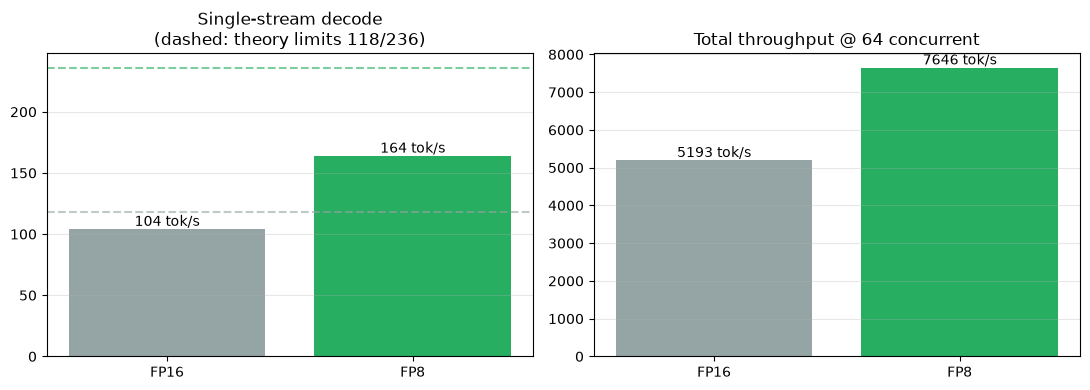

单流 ×1.58（理论 ×2.0，反量化开销吃掉 0.4）
高并发 ×1.47（高并发更接近算力瓶颈，量化收益递减——roofline 预言再次命中）


In [2]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# 单流 decode
b1 = ax1.bar(["FP16", "FP8"], [104, 163.9], color=["#95a5a6", "#27ae60"])
ax1.axhline(118, ls="--", color="#95a5a6", alpha=0.6)
ax1.axhline(236, ls="--", color="#27ae60", alpha=0.6)
ax1.bar_label(b1, fmt="%.0f tok/s")
ax1.set_title("Single-stream decode\n(dashed: theory limits 118/236)")
ax1.grid(alpha=0.3, axis="y")

# 64 并发总吞吐
b2 = ax2.bar(["FP16", "FP8"], [5193, 7646], color=["#95a5a6", "#27ae60"])
ax2.bar_label(b2, fmt="%.0f tok/s")
ax2.set_title("Total throughput @ 64 concurrent")
ax2.grid(alpha=0.3, axis="y")

plt.tight_layout(); plt.savefig("/workspace/week06_fp8.png", dpi=120); plt.show()
print("单流 ×1.58（理论 ×2.0，反量化开销吃掉 0.4）")
print("高并发 ×1.47（高并发更接近算力瓶颈，量化收益递减——roofline 预言再次命中）")

## 3. 账三：质量对照（6 题抽查）

temperature=0，同题同参，FP8 vs FP16：

| 题目 | FP8 正确? | 与 FP16 逐字一致? |
|---|---|---|
| 巴黎人口 | ✅ 220万 | 否（措辞略异，语义等价）|
| 铁 vs 棉花 | ✅ 一样重 | 否（语义等价）|
| 星期推理 | ✅ 星期六 | 否（语义等价）|
| 量子纠缠 | ✅ 准确 | 否（语义等价）|
| 七言诗 | ✅ 合格 | **是（一字不差）** |
| 17×23 | ✅ 391 | 否（路径不同，都对）|

> 📌 **FP8 的真实面貌：输出不会逐字相同，但质量几乎无损。**
> 质量敏感业务应该用业务题集做正式验收，而不是假设逐字一致。
> 重跑：`python3 /workspace/quality_check.py fp8`（或 fp16）

## 4. 本周结论卡

```
FP8 在线量化（Qwen2.5-7B @ RTX 5090）
├─ 速度：单流 ×1.58，64并发 ×1.47
├─ 显存：KV 池 +30%（25.3万→33万 token）
├─ 质量：6/6 正确，语义无损
└─ 成本：零（一条启动参数，无需新权重）
→ 结论：无脑开 ✅
```

## 5. 扩展思考

1. 为什么高并发下 FP8 收益（×1.47）比单流（×1.58）低？（提示：roofline——高并发推向算力瓶颈区）
2. 如果再加上 FP8 KV Cache（`--kv-cache-dtype fp8`），KV 池还能翻几倍？
3. INT4 AWQ 预计单流多少 tok/s？（理论上限 470，按本次折扣率估算）

## 6. 下一站

➡️ **Week 7 投机解码 + KV 驱逐**：用闲置算力"猜"token，以及长上下文的显存救星。